# 05 — Annotations
**Goal:** Add context to charts — the difference between a chart that shows data and one that tells a story.

Topics:
- `ax.text()` — free text anywhere
- `ax.annotate()` — text with an arrow pointing at something
- Highlight regions with `axvspan` / `axhspan`
- Reference lines with `axhline` / `axvline`
- LaTeX math in labels

In [1]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams.update({
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.size':         11,
})

df = pd.read_csv('data/raw/funnel_data.csv', parse_dates=['date'])
daily = df.groupby('date').agg(
    sessions=('visita_landing', 'sum'),
    activations=('activacion_tarjeta', 'sum')
).reset_index()
print('Ready')

Ready


## 1. `ax.text()` — add text anywhere on the chart

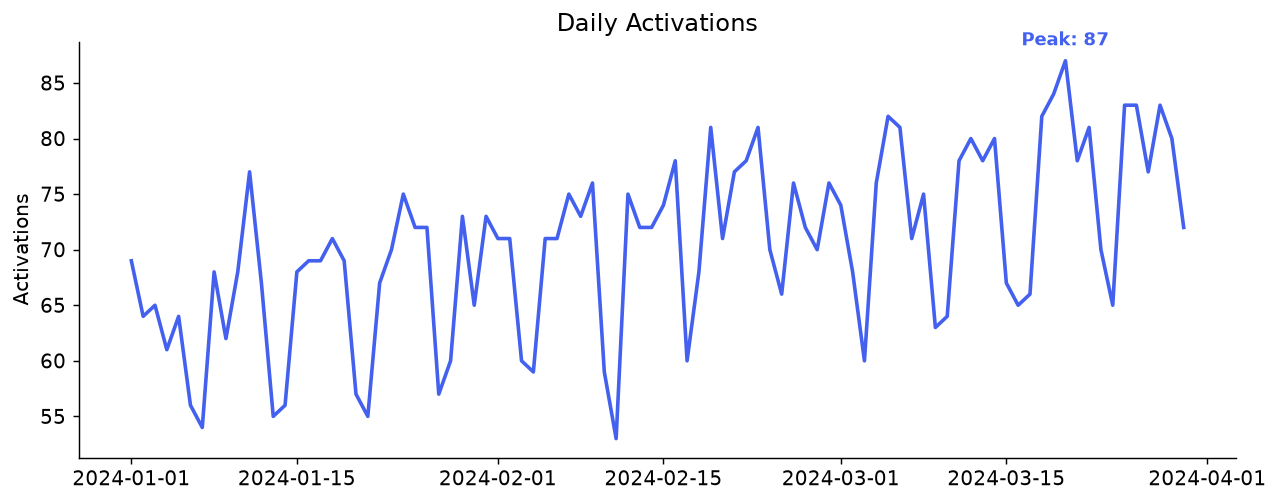

In [2]:
fig, ax = plt.subplots(figsize=(10, 4), dpi=130)

ax.plot(daily['date'], daily['activations'], color='#4361ee', linewidth=2)
ax.set_title('Daily Activations')
ax.set_ylabel('Activations')

# ax.text(x, y, 'text')
# x and y are in data coordinates (same units as the axis)
peak_date = daily.loc[daily['activations'].idxmax(), 'date']
peak_val  = daily['activations'].max()

ax.text(peak_date, peak_val + 1,          # position: slightly above the peak
        f'Peak: {int(peak_val)}',
        ha='center', va='bottom',          # horizontal and vertical alignment
        fontsize=10, color='#4361ee', fontweight='bold')

plt.tight_layout()
plt.show()

## 2. `ax.annotate()` — text with an arrow
Use this to call attention to a specific data point and explain why it matters.

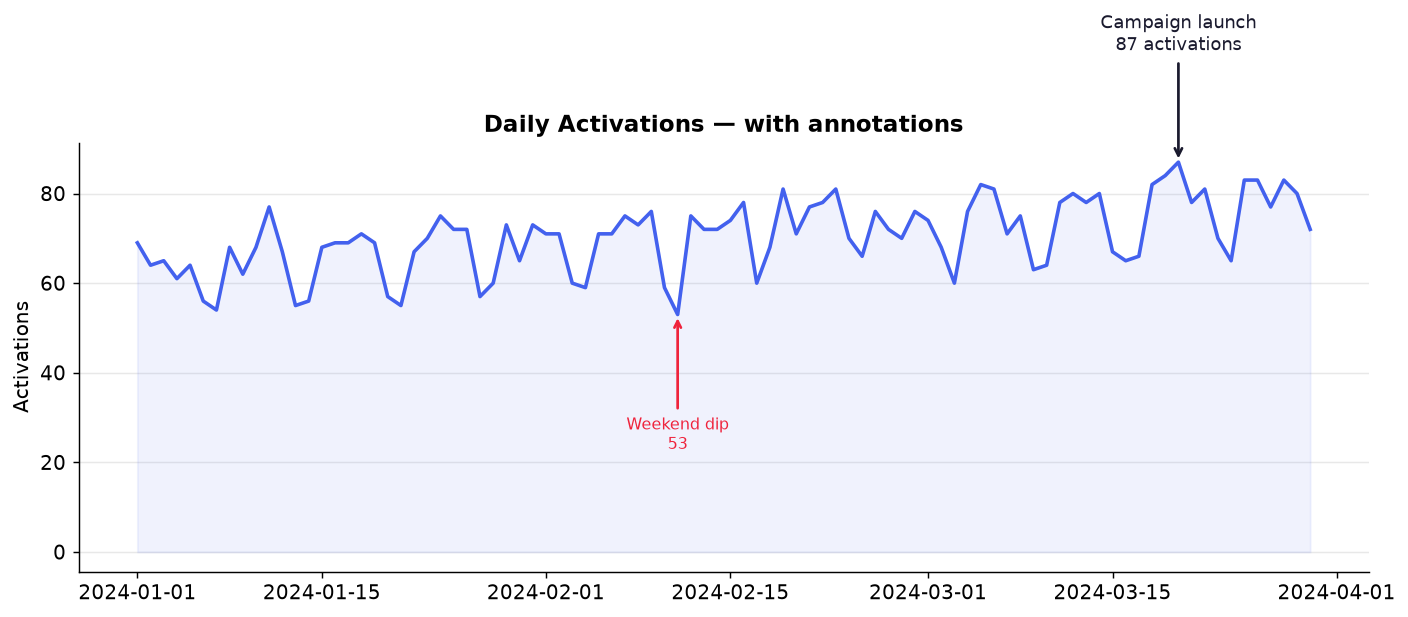

In [3]:
fig, ax = plt.subplots(figsize=(11, 5), dpi=130)

ax.plot(daily['date'], daily['activations'], color='#4361ee', linewidth=2)
ax.fill_between(daily['date'], daily['activations'], alpha=0.08, color='#4361ee')
ax.set_title('Daily Activations — with annotations', fontsize=13, fontweight='bold')
ax.set_ylabel('Activations')

# Annotate the peak
peak_date = daily.loc[daily['activations'].idxmax(), 'date']
peak_val  = daily['activations'].max()

ax.annotate(
    f'Campaign launch\n{peak_val:.0f} activations',
    xy=(peak_date, peak_val),              # arrow tip — points at the data
    xytext=(peak_date, peak_val + 25),     # text position — above the tip
    ha='center',
    fontsize=10,
    color='#1a1a2e',
    arrowprops=dict(
        arrowstyle='->',                   # arrow shape
        color='#1a1a2e',
        lw=1.5
    )
)

# Annotate the minimum
min_date = daily.loc[daily['activations'].idxmin(), 'date']
min_val  = daily['activations'].min()

ax.annotate(
    f'Weekend dip\n{min_val:.0f}',
    xy=(min_date, min_val),
    xytext=(min_date, min_val - 30),
    ha='center',
    fontsize=9,
    color='#ef233c',
    arrowprops=dict(arrowstyle='->', color='#ef233c', lw=1.5)
)

ax.grid(axis='y', color='#e8e8e8', linewidth=0.8)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## 3. Reference lines — `axhline` and `axvline`

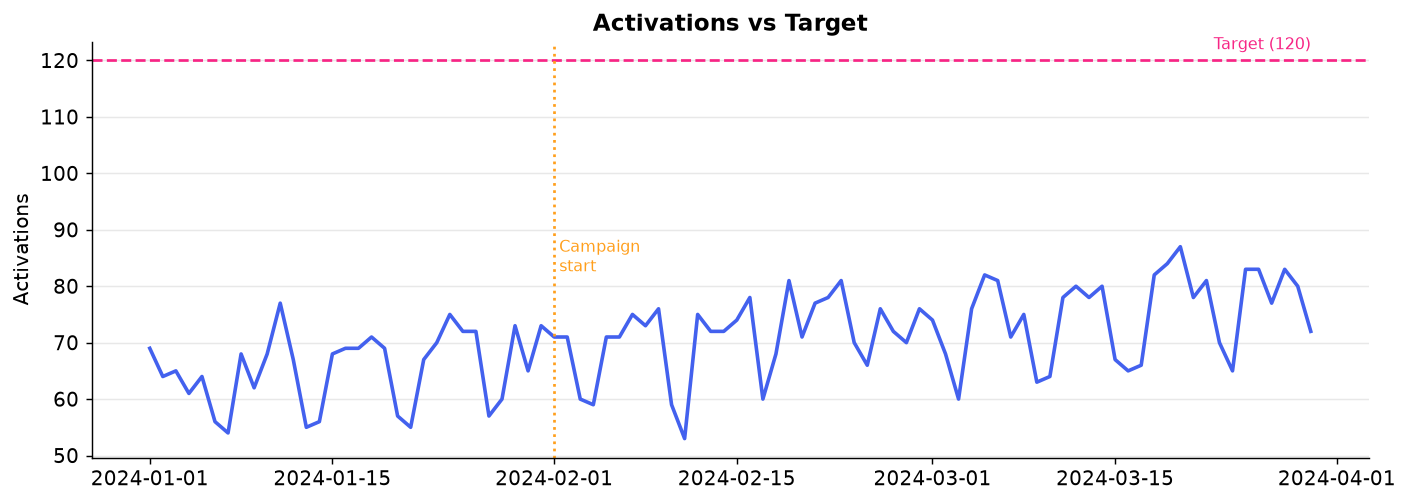

In [4]:
fig, ax = plt.subplots(figsize=(11, 4), dpi=130)

ax.plot(daily['date'], daily['activations'], color='#4361ee', linewidth=2)
ax.set_title('Activations vs Target', fontsize=13, fontweight='bold')
ax.set_ylabel('Activations')

target = 120   # hypothetical daily target

# axhline = horizontal reference line
ax.axhline(y=target,
           color='#f72585', linewidth=1.5, linestyle='--',
           label=f'Target: {target}')

# Label the line on the right side
ax.text(daily['date'].max(), target + 2,
        f'Target ({target})',
        color='#f72585', fontsize=9, ha='right')

# axvline = vertical reference line (e.g., a campaign start date)
campaign_start = pd.Timestamp('2024-02-01')
ax.axvline(x=campaign_start,
           color='#ff9f1c', linewidth=1.5, linestyle=':')
ax.text(campaign_start, daily['activations'].max() * 0.95,
        ' Campaign\n start', color='#ff9f1c', fontsize=9)

ax.grid(axis='y', color='#e8e8e8', linewidth=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## 4. Highlighted regions — `axvspan` and `axhspan`

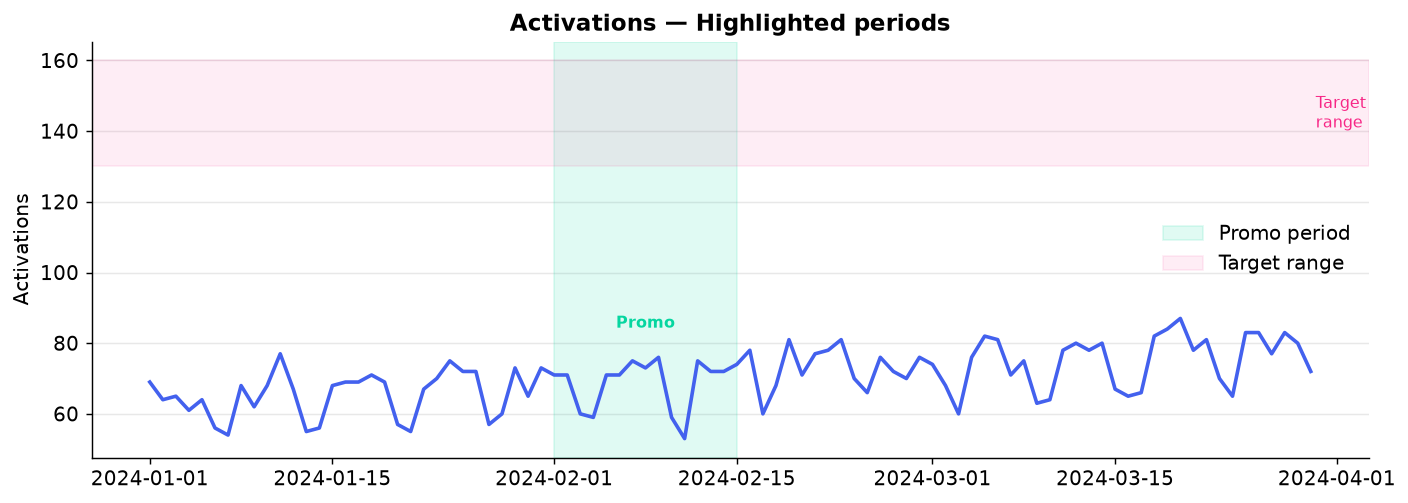

In [5]:
fig, ax = plt.subplots(figsize=(11, 4), dpi=130)

ax.plot(daily['date'], daily['activations'], color='#4361ee', linewidth=2)
ax.set_title('Activations — Highlighted periods', fontsize=13, fontweight='bold')
ax.set_ylabel('Activations')

# axvspan shades a vertical band between two x values
# alpha controls transparency
ax.axvspan(pd.Timestamp('2024-02-01'), pd.Timestamp('2024-02-15'),
           alpha=0.12, color='#06d6a0', label='Promo period')
ax.text(pd.Timestamp('2024-02-08'), daily['activations'].max() * 0.97,
        'Promo', ha='center', fontsize=9, color='#06d6a0', fontweight='bold')

# axhspan shades a horizontal band between two y values
ax.axhspan(ymin=130, ymax=160,
           alpha=0.08, color='#f72585', label='Target range')
ax.text(daily['date'].max(), 145,
        ' Target\n range', fontsize=9, color='#f72585', va='center')

ax.legend(frameon=False)
ax.grid(axis='y', color='#e8e8e8', linewidth=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## 5. LaTeX math in labels
Wrap expressions in `$...$`. Use raw strings `r'...'` to avoid Python interpreting backslashes.

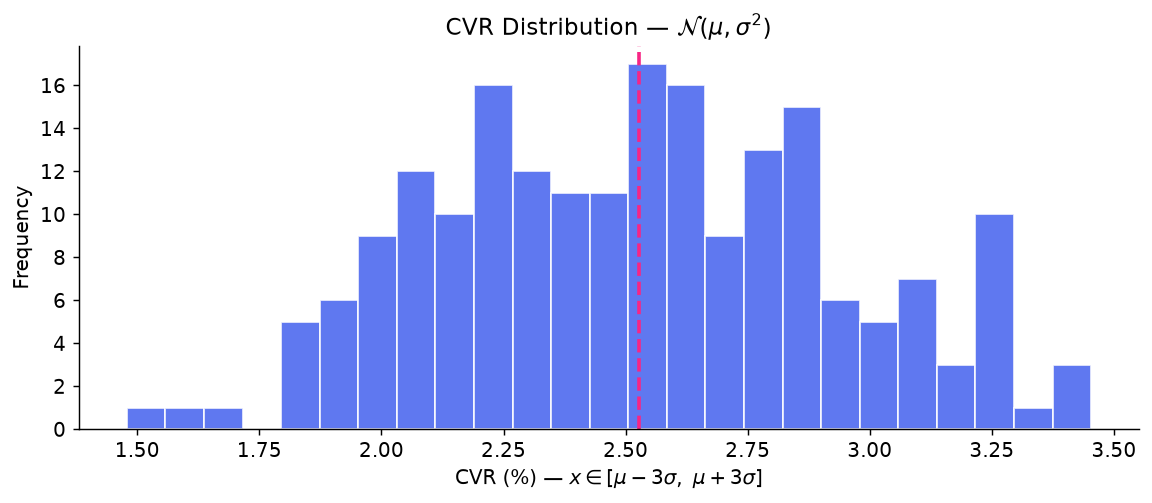

In [6]:
np.random.seed(0)
x = np.linspace(0, 10, 200)
cvr = np.random.normal(loc=2.5, scale=0.4, size=200)

fig, ax = plt.subplots(figsize=(9, 4), dpi=130)

ax.hist(cvr, bins=25, color='#4361ee', edgecolor='white', alpha=0.85)

mu  = np.mean(cvr)
sig = np.std(cvr)

ax.axvline(mu, color='#f72585', linewidth=2, linestyle='--')

# LaTeX in title and axis labels
ax.set_title(r'CVR Distribution — $\mathcal{N}(\mu, \sigma^2)$', fontsize=13)
ax.set_xlabel(r'CVR (%) — $x \in [\mu - 3\sigma,\ \mu + 3\sigma]$', fontsize=11)
ax.set_ylabel('Frequency')

# LaTeX in annotation
ax.annotate(
    rf'$\mu = {mu:.2f}$, $\sigma = {sig:.2f}$',
    xy=(mu, 20),
    xytext=(mu + 0.3, 22),
    fontsize=11,
    arrowprops=dict(arrowstyle='->', color='#1a1a2e')
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# LaTeX cheat sheet:
# r'$\mu$'      → μ      (mean)
# r'$\sigma$'   → σ      (std dev)
# r'$\alpha$'   → α
# r'$x^2$'      → x²
# r'$x_{i}$'    → x subscript i
# r'$\bar{x}$'  → x̄     (sample mean)
# r'$\frac{a}{b}$' → a/b (fraction)

## 6. Full annotated chart — presentation ready

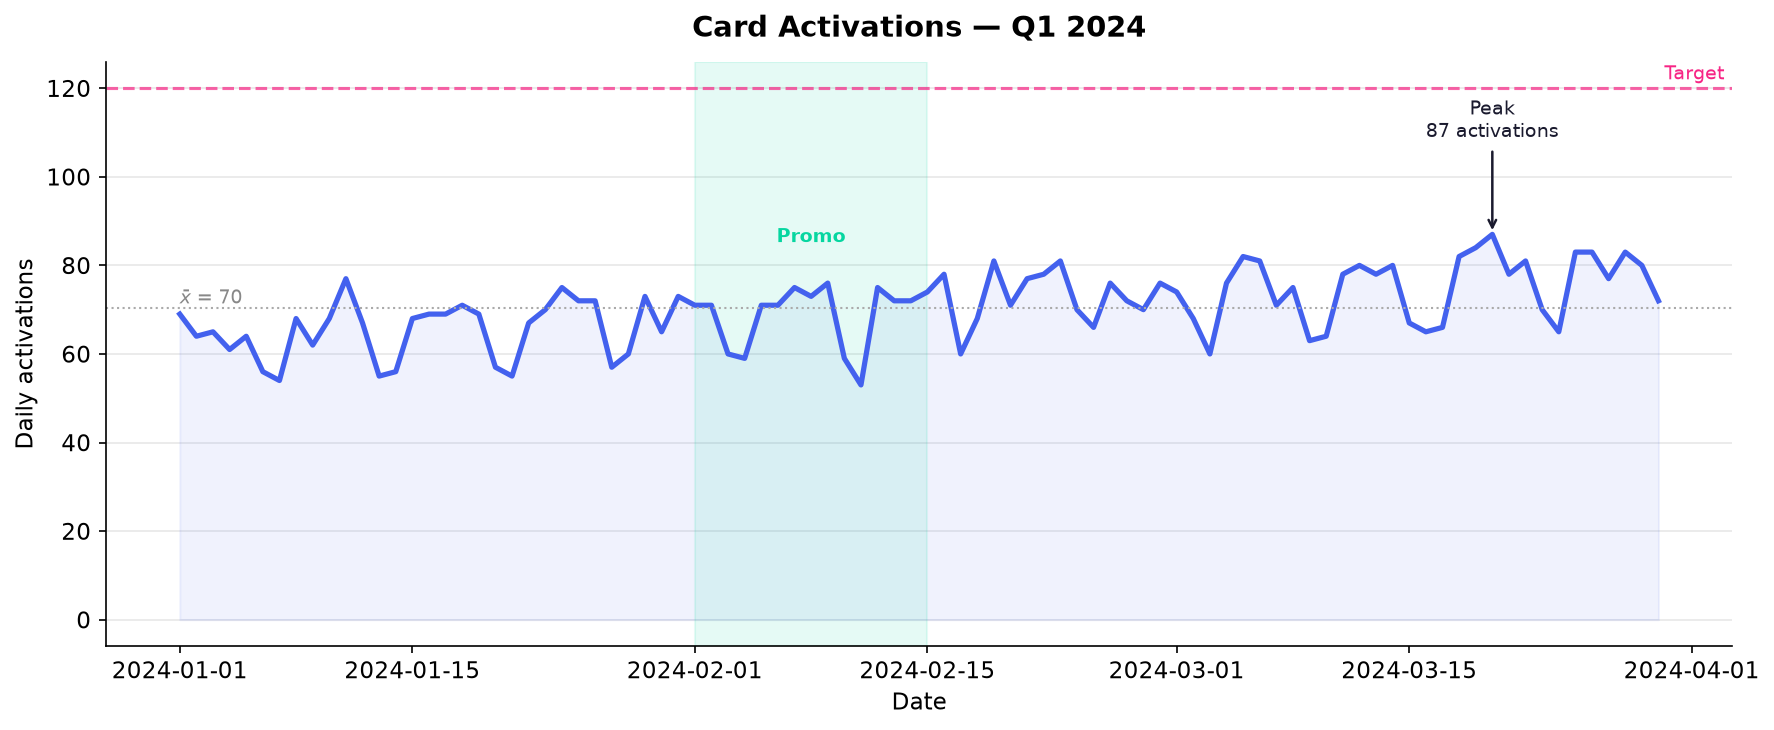

In [7]:
fig, ax = plt.subplots(figsize=(12, 5), dpi=150)

ax.plot(daily['date'], daily['activations'], color='#4361ee', linewidth=2.5)
ax.fill_between(daily['date'], daily['activations'], alpha=0.08, color='#4361ee')

# Target line
ax.axhline(y=120, color='#f72585', linewidth=1.5, linestyle='--', alpha=0.7)
ax.text(daily['date'].max(), 121, ' Target', color='#f72585', fontsize=9, va='bottom')

# Promotion period
ax.axvspan(pd.Timestamp('2024-02-01'), pd.Timestamp('2024-02-15'),
           alpha=0.1, color='#06d6a0')
ax.text(pd.Timestamp('2024-02-08'), daily['activations'].max() * 0.98,
        'Promo', ha='center', fontsize=9, color='#06d6a0', fontweight='bold')

# Peak annotation
peak_date = daily.loc[daily['activations'].idxmax(), 'date']
peak_val  = daily['activations'].max()
ax.annotate(f'Peak\n{peak_val:.0f} activations',
            xy=(peak_date, peak_val),
            xytext=(peak_date, peak_val + 22),
            ha='center', fontsize=9, color='#1a1a2e',
            arrowprops=dict(arrowstyle='->', color='#1a1a2e', lw=1.2))

# Mean line
mean_val = daily['activations'].mean()
ax.axhline(mean_val, color='#aaa', linewidth=1, linestyle=':')
ax.text(daily['date'].min(), mean_val + 1,
        rf'$\bar{{x}}$ = {mean_val:.0f}', fontsize=9, color='#888')

ax.set_title('Card Activations — Q1 2024', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Daily activations')
ax.set_xlabel('Date')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', color='#e8e8e8', linewidth=0.8)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('data/05_annotated_chart.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary
| Tool | What it does |
|---|---|
| `ax.text(x, y, 'txt')` | Free text at data coordinates |
| `ax.annotate('txt', xy=, xytext=)` | Text + arrow pointing at a point |
| `ax.axhline(y=val)` | Horizontal reference line |
| `ax.axvline(x=val)` | Vertical reference line |
| `ax.axvspan(x1, x2)` | Shaded vertical region |
| `ax.axhspan(y1, y2)` | Shaded horizontal band |
| `r'$\mu$'` | LaTeX math in any text |

**Next:** `06_statistical_plots.ipynb` — error bars, confidence intervals, regression lines.